In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df= pd.read_csv('/content/unicorns till sep 2022.csv')

In [ ]:
df

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,04-07-2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12-01-2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,07-03-2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,01-08-2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
...,...,...,...,...,...,...,...
1181,LeadSquared,$1,6/21/2022,India,Bengaluru,Internet software & services,"Gaja Capital Partners, Stakeboat Capital, West..."
1182,FourKites,$1,6/21/2022,United States,Chicago,"Supply chain, logistics, & delivery","Hyde Park Venture Partners, Bain Capital Ventu..."
1183,VulcanForms,$1,07-05-2022,United States,Burlington,"Supply chain, logistics, & delivery","Eclipse Ventures, D1 Capital Partners, Industr..."
1184,SingleStore,$1,07-12-2022,United States,San Francisco,Data management & analytics,"Google Ventures, Accel, Data Collective"


In [ ]:
df= df.dropna()

In [39]:
# Remove $ symbol and convert valuation to float
df['Valuation ($B)'] = df['Valuation ($B)'].replace('[\$,]', '', regex=True).astype(float)

# Convert 'Date Joined' to datetime
df['Date Joined'] = pd.to_datetime(df['Date Joined'], errors='coerce')


<ipython-input-39-fe308035db12>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Valuation ($B)'] = df['Valuation ($B)'].replace('[\$,]', '', regex=True).astype(float)
<ipython-input-39-fe308035db12>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date Joined'] = pd.to_datetime(df['Date Joined'], errors='coerce')


##Exploring the Data

In [40]:
df

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors,Year Joined
0,ByteDance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2017.0
1,SpaceX,127.0,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012.0
2,SHEIN,100.0,2018-07-03,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China...",2018.0
3,Stripe,95.0,NaT,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2021.0
4,Canva,40.0,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",2018.0
...,...,...,...,...,...,...,...,...
1181,LeadSquared,1.0,NaT,India,Bengaluru,Internet software & services,"Gaja Capital Partners, Stakeboat Capital, West...",2021.0
1182,FourKites,1.0,NaT,United States,Chicago,"Supply chain, logistics, & delivery","Hyde Park Venture Partners, Bain Capital Ventu...",2021.0
1183,VulcanForms,1.0,2022-07-05,United States,Burlington,"Supply chain, logistics, & delivery","Eclipse Ventures, D1 Capital Partners, Industr...",2022.0
1184,SingleStore,1.0,2022-07-12,United States,San Francisco,Data management & analytics,"Google Ventures, Accel, Data Collective",2022.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 0 to 1185
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Company         1168 non-null   object        
 1   Valuation ($B)  1168 non-null   float64       
 2   Date Joined     450 non-null    datetime64[ns]
 3   Country         1168 non-null   object        
 4   City            1168 non-null   object        
 5   Industry        1168 non-null   object        
 6   Investors       1168 non-null   object        
 7   Year Joined     1168 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 82.1+ KB


In [30]:
df.describe()


,Valuation ($B),Date Joined,Year Joined
count,1168.000000,450,1168.000000
mean,3.251087,2020-07-25 03:18:24,2020.656678
min,1.000000,2007-07-02 00:00:00,2007.000000
25%,1.100000,2019-08-06 06:00:00,2021.000000
50%,1.600000,2021-05-09 12:00:00,2021.000000
75%,3.000000,2021-11-10 18:00:00,2021.000000
max,140.000000,2022-08-10 00:00:00,2022.000000
std,7.650835,NaN,1.370308


In [31]:
print("Industries:", df['Industry'].nunique())
print("Countries:", df['Country'].nunique())

Industries: 17
Countries: 46


In [32]:
top10 = df.sort_values(by='Valuation ($B)', ascending=False).head(10)
top10[['Company', 'Valuation ($B)']]


,Company,Valuation ($B)
0,ByteDance,140.0
1,SpaceX,127.0
2,SHEIN,100.0
3,Stripe,95.0
4,Canva,40.0
5,Checkout.com,40.0
6,Instacart,39.0
7,Databricks,38.0
8,Revolut,33.0
9,Epic Games,31.5


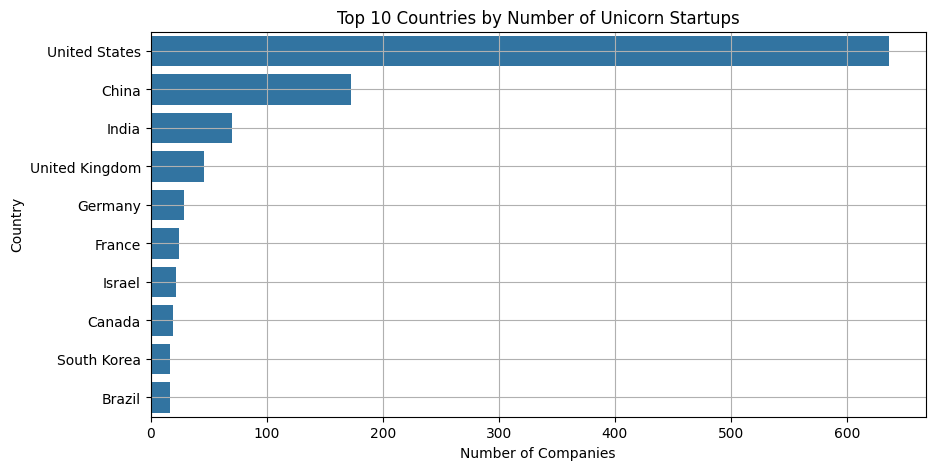

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Country', order=df['Country'].value_counts().head(10).index)
plt.title('Top 10 Countries by Number of Unicorn Startups')
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.grid(True)
plt.show()


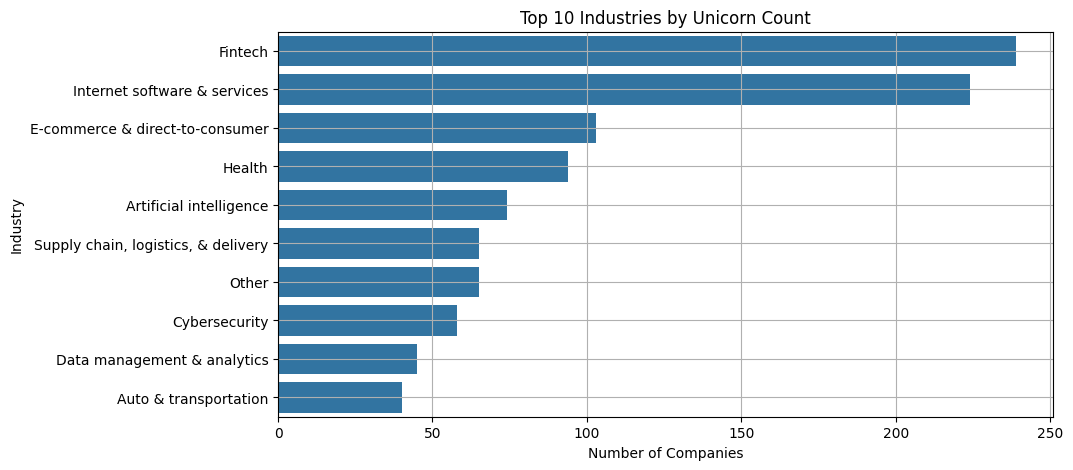

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Industry', order=df['Industry'].value_counts().head(10).index)
plt.title('Top 10 Industries by Unicorn Count')
plt.xlabel('Number of Companies')
plt.ylabel('Industry')
plt.grid(True)
plt.show()


<ipython-input-14-fdca6975bd97>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year Joined'] = df['Date Joined'].dt.year


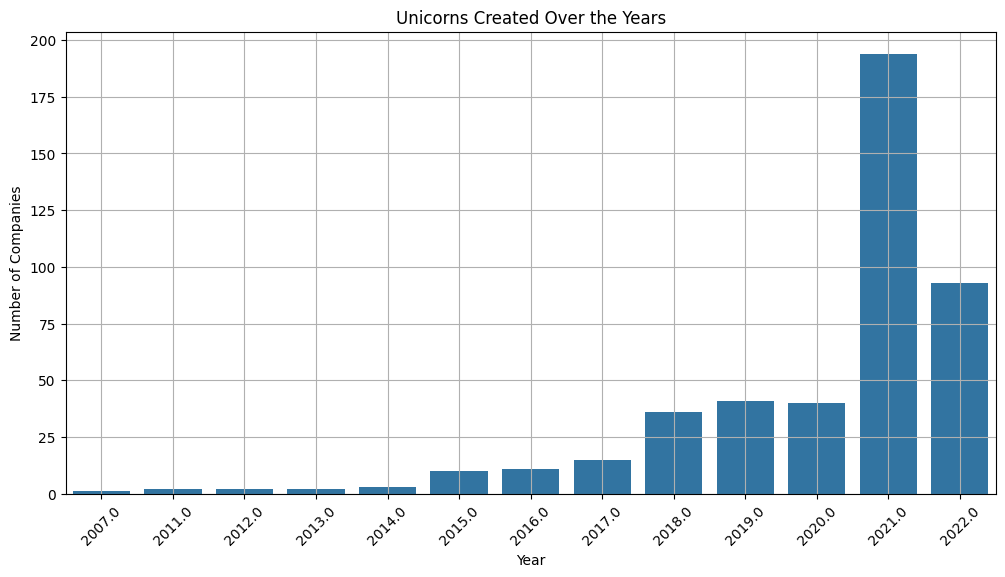

In [ ]:
df['Year Joined'] = df['Date Joined'].dt.year

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Year Joined', order=sorted(df['Year Joined'].dropna().unique()))
plt.title('Unicorns Created Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


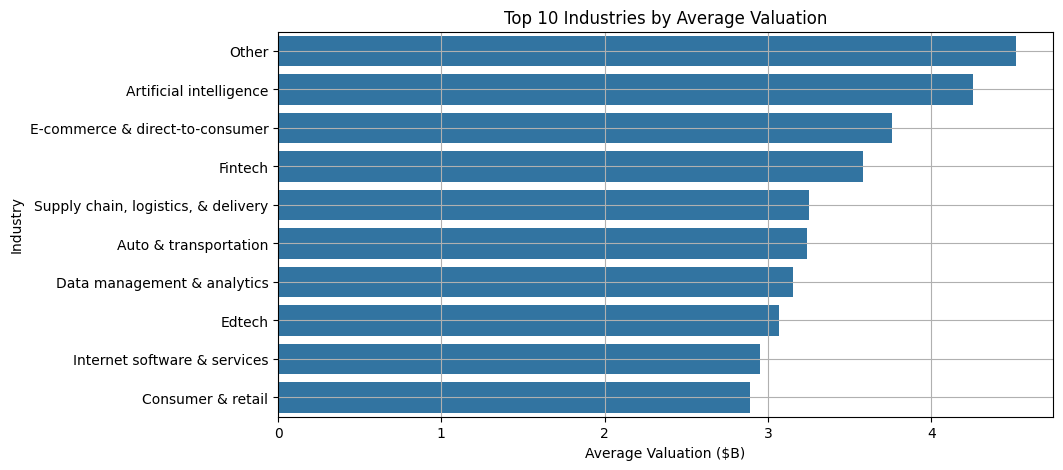

In [ ]:
industry_val = df.groupby('Industry')['Valuation ($B)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=industry_val.values, y=industry_val.index)
plt.title('Top 10 Industries by Average Valuation')
plt.xlabel('Average Valuation ($B)')
plt.ylabel('Industry')
plt.grid(True)
plt.show()


In [ ]:
#Show all companies backed by 'Sequoia Capital'
df[df['Investors'].str.contains('Sequoia Capital', na=False)][['Company', 'Valuation ($B)', 'Investors']]


,Company,Valuation ($B),Investors
0,ByteDance,140.0,"Sequoia Capital China, SIG Asia Investments, S..."
2,SHEIN,100.0,"Tiger Global Management, Sequoia Capital China..."
4,Canva,40.0,"Sequoia Capital China, Blackbird Ventures, Mat..."
13,BYJU's,22.0,"Tencent Holdings, Lightspeed India Partners, S..."
15,J&T Express,20.0,"Hillhouse Capital Management, Boyu Capital, Se..."
...,...,...,...
1087,MobiKwik,1.0,"Sequoia Capital India, The Times Group, GMO Ve..."
1095,Tezign,1.0,"Sequoia Capital China, Linear Venture, Hearst ..."
1127,Kopi Kenangan,1.0,"Horizons Ventures, Sequoia Capital India, Alph..."
1134,Darwinbox,1.0,"Lightspeed India Partners, Sequoia Capital Ind..."


##Model Building

In [42]:
# Data Segregation
X = df.drop(columns='Valuation ($B)')
y = df['Valuation ($B)']

In [43]:
# Categorical and numerical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer([ ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),('num', StandardScaler(), num_features)])

In [44]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [50]:
# Model
model = Pipeline(steps=[('preprocess', preprocessor),('regressor', RandomForestRegressor(random_state=42))])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.12155665901123824
RMSE: 2.9614040609951613


In [51]:
# Grid search parameters
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [5, 10, 15],
}

grid_search = GridSearchCV(model, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Params: {'regressor__max_depth': 15, 'regressor__n_estimators': 100}
Best R2 Score: -0.0033818371884503096


In [52]:
# Final model
best_model = grid_search.best_estimator_
y_final_pred = best_model.predict(X_test)

print("Final R2 Score:", r2_score(y_test, y_final_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_final_pred)))


Final R2 Score: 0.06750073163283876
Final RMSE: 2.700295597438535


##Result

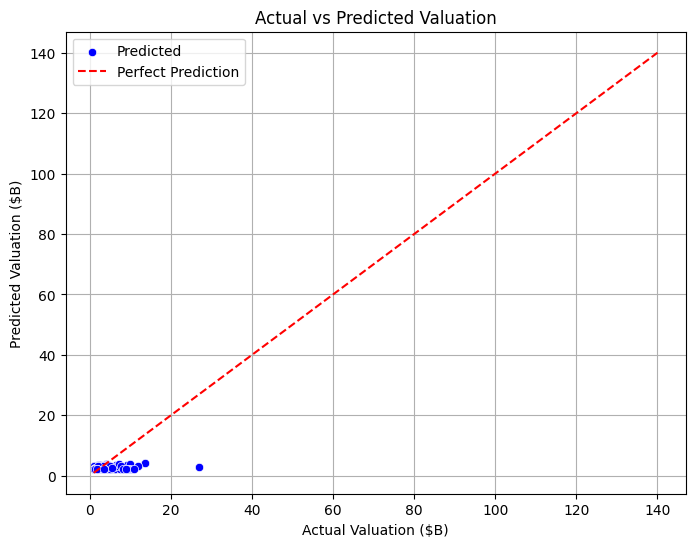

In [53]:
plt.figure(figsize=(8,6))

# Plot actual vs predicted points
sns.scatterplot(x=y_test, y=y_final_pred, color='blue', label='Predicted')

# Plot perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Valuation ($B)")
plt.ylabel("Predicted Valuation ($B)")
plt.title("Actual vs Predicted Valuation")
plt.legend()
plt.grid(True)
plt.show()
